# char_06 — Isolating the dry-season anomaly

## Purpose

`char_05` scored every Addis filter against two reference classes — McCall raw feedstock
and McCall char — and the Dry-season filters did not behave like the others. They sat
well above the 1:1 line (raw biomass the better analogue) and at much lower absolute
similarity to char. Belg and Kiremt filters sat tidily on the line.

That scatter also hinted at something the seasonal medians hide: the Dry season looked
like it might be **two populations**, not one shifted population — some Dry filters
behaved perfectly normally.

This notebook isolates it and asks three questions in order:

1. **Is it real, or is it the filter lot?** ETAD spectra come from two PTFE lots, and lot
   248 is heavily dry-season. This has to be settled before anything else is worth saying.
2. **Is the Dry season one population or two**, and if two, what separates them?
3. **What do the anomalous spectra actually look like**, and what covaries with them?

The answer to (1) determines whether the rest of the notebook is atmospheric science or
an instrument post-mortem, so it comes first.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from sklearn.mixture import GaussianMixture

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, ramp_score,
    band_area, BANDS,
)
from etad_spectra import load_etad
from phase3_common import PATHS

PLOT_DIR = Path("output/plots/char06")
TABLE_DIR = Path("output/tables/char06")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   McCall: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)


GRID = np.arange(1430.0, 3500.0 + 1e-9, 2.0)

## Reproduce the char_05 scoring, and attach the filter lot

In [2]:
sets = load_all()
mc_meta = pd.concat(
    [sets["mccall_multi"].meta, sets["mccall_barley"].meta], ignore_index=True)
X_mc = snv(detrend(np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID)]), GRID))
unburned = (mc_meta["temp_c"] == 0).to_numpy()
char = (mc_meta["temp_c"] > 0).to_numpy()

etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
X_addis = prepare(X_etad_base, wn_etad_b, GRID)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID)


def zrows(X):
    return (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)


R = (zrows(X_addis) @ zrows(X_mc).T) / GRID.size

df = pd.DataFrame({
    "MediaId": etad_meta["MediaId"].to_numpy(),
    "FilterId": etad_meta["ExternalFilterId"].to_numpy(),
    "date": pd.to_datetime(etad_meta["SamplingStartDate"].to_numpy()),
    "season": etad_meta["season"].map(SEASON_MAP).to_numpy(),
    "Fabs": etad_meta["Fabs"].to_numpy(),
    "EC": etad_meta["EC_deployed_ugm3"].to_numpy(),
    "r_char": R[:, char].max(axis=1),
    "r_raw": R[:, unburned].max(axis=1),
})
df["delta"] = df["r_raw"] - df["r_char"]
df["month"] = df["date"].dt.month
df["is_dry"] = df["season"] == "Dry Season"

# Filter lot — the confounder that has to be ruled out.
lots = pd.read_csv(PATHS.etad_dir / "etad_spectra_lotmap.csv")
df = df.merge(lots[["MediaId", "LotId"]].drop_duplicates("MediaId"),
              on="MediaId", how="left")

print(f"{len(df)} filters, lot known for {df['LotId'].notna().sum()}")
display(df.groupby("season")[["r_char", "r_raw", "delta"]].median().round(3))

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
239 filters, lot known for 190


,r_char,r_raw,delta
season,,,
Belg Rainy Season,0.686,0.684,0.012
Dry Season,0.406,0.531,0.062
Kiremt Rainy Season,0.615,0.616,0.008


## 1. Is it the filter lot? — the control that has to pass first

ETAD spectra come from two PTFE lots. Lot 248 is **heavily dry-season** (27 of its 34
filters, and none at all in Kiremt), so lot and season are confounded in the raw
crosstab. Two tests separate them:

* **Within lot 251 alone** — which spans all three seasons — does the Dry season still
  stand out? If yes, season is doing the work.
* **Within the Dry season alone**, does lot matter? If no, the lot is not doing the work.

In [3]:
print("lot × season crosstab (the confounding):")
display(pd.crosstab(df["LotId"], df["season"]))

within_251 = df[df["LotId"] == 251]
t1 = within_251.groupby("season").agg(
    filters=("delta", "size"), median_r_char=("r_char", "median"),
    median_delta=("delta", "median")).round(3)
print("\nTEST 1 — within lot 251 only (spans all seasons):")
display(t1)
dry_d = within_251.loc[within_251["is_dry"], "delta"]
wet_d = within_251.loc[~within_251["is_dry"], "delta"]
u1 = stats.mannwhitneyu(dry_d, wet_d)
print(f"  Mann–Whitney, dry vs non-dry within lot 251: U={u1.statistic:.0f}, "
      f"p={u1.pvalue:.2e}")

within_dry = df[df["is_dry"] & df["LotId"].notna()]
t2 = within_dry.groupby("LotId").agg(
    filters=("delta", "size"), median_r_char=("r_char", "median"),
    median_delta=("delta", "median")).round(3)
print("\nTEST 2 — within the Dry season only, split by lot:")
display(t2)
a = within_dry.loc[within_dry["LotId"] == 248, "delta"]
b = within_dry.loc[within_dry["LotId"] == 251, "delta"]
u2 = stats.mannwhitneyu(a, b)
print(f"  Mann–Whitney, lot 248 vs 251 within the dry season: U={u2.statistic:.0f}, "
      f"p={u2.pvalue:.3f}")

t1.to_csv(TABLE_DIR / "lot_control_within_lot251.csv")
t2.to_csv(TABLE_DIR / "lot_control_within_dry.csv")

lot × season crosstab (the confounding):


season,Belg Rainy Season,Dry Season,Kiremt Rainy Season
LotId,,,
248.0,7,27,0
251.0,44,46,66



TEST 1 — within lot 251 only (spans all seasons):


,filters,median_r_char,median_delta
season,,,
Belg Rainy Season,44,0.731,0.013
Dry Season,46,0.400,0.063
Kiremt Rainy Season,66,0.616,0.008


  Mann–Whitney, dry vs non-dry within lot 251: U=4284, p=9.42e-12

TEST 2 — within the Dry season only, split by lot:


,filters,median_r_char,median_delta
LotId,,,
248.0,27,0.458,0.070
251.0,46,0.400,0.063


  Mann–Whitney, lot 248 vs 251 within the dry season: U=634, p=0.886


**The lot is not the explanation.** Within a single lot the Dry season separates at
p ≈ 1e-11; within a single season the two lots are indistinguishable (p ≈ 0.9). The
effect follows the calendar, not the filter stock.

## 2. It recurs every year, which no instrument artifact does

The strongest evidence that this is atmospheric rather than instrumental is that it
switches on and off with the calendar, repeatedly, across four years of sampling.

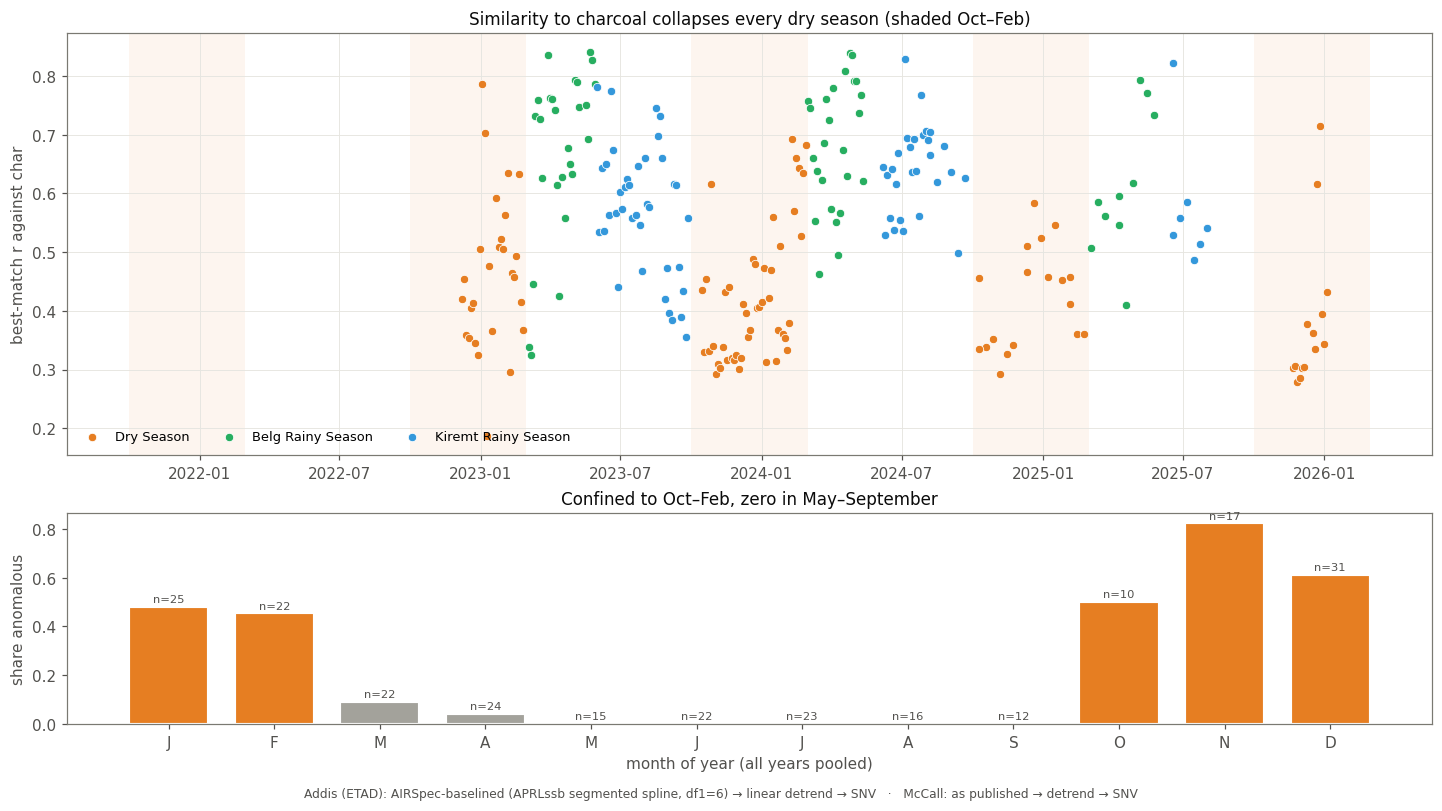

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
for season, color in SEASON_COLORS.items():
    m = (df["season"] == season).to_numpy()
    ax.scatter(df.loc[m, "date"], df.loc[m, "r_char"], s=30, c=color,
               edgecolor="white", linewidth=0.5, label=season, zorder=3)
for yr in range(2022, 2027):
    ax.axvspan(pd.Timestamp(f"{yr-1}-10-01"), pd.Timestamp(f"{yr}-03-01"),
               color=SEASON_COLORS["Dry Season"], alpha=0.07, lw=0, zorder=0)
ax.set_ylabel("best-match r against char", color=INK2)
ax.set_title("Similarity to charcoal collapses every dry season (shaded Oct–Feb)",
             color=INK)
ax.legend(fontsize=8.5, ncol=3, loc="lower left")

ax = axes[1]
monthly = df.groupby("month").agg(rate=("delta", lambda v: (v > 0.05).mean()),
                                  n=("delta", "size"))
bars = ax.bar(monthly.index, monthly["rate"], color=[
    SEASON_COLORS["Dry Season"] if m in (10, 11, 12, 1, 2) else MUTED
    for m in monthly.index], width=0.75, edgecolor="white", linewidth=1.4)
for m, row in monthly.iterrows():
    ax.annotate(f"n={int(row['n'])}", (m, row["rate"]), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=7.5, color=INK2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_xlabel("month of year (all years pooled)", color=INK2)
ax.set_ylabel("share anomalous", color=INK2)
ax.set_title("Confined to Oct–Feb, zero in May–September", color=INK)
ax.grid(False)

stamp(fig)
fig.savefig(PLOT_DIR / "01_seasonal_recurrence.png", dpi=160, bbox_inches="tight")
plt.show()
monthly.round(3).to_csv(TABLE_DIR / "monthly_anomaly_rate.csv")

## 3. One population or two?

The seasonal medians would be equally consistent with "all dry-season filters shift a
little" or "some dry-season filters shift a lot". A two-component Gaussian mixture on
the char-similarity, fitted without any season information, decides it — and its
split is then compared against the calendar it never saw.

In [5]:
gm = GaussianMixture(n_components=2, random_state=RANDOM_SEED, n_init=10)
vals = df[["r_char"]].to_numpy()
gm.fit(vals)
comp_order = np.argsort(gm.means_.ravel())          # 0 = low-similarity component
df["component"] = np.where(gm.predict(vals) == comp_order[0], "low-similarity", "normal")

gm1 = GaussianMixture(n_components=1, random_state=RANDOM_SEED).fit(vals)
print(f"BIC — 1 component: {gm1.bic(vals):.1f}   2 components: {gm.bic(vals):.1f}")
print(f"  → {'two components preferred' if gm.bic(vals) < gm1.bic(vals) else 'one component preferred'}")
print(f"component means: {np.sort(gm.means_.ravel()).round(3)}, "
      f"weights: {gm.weights_[comp_order].round(3)}")

print("\nthe mixture split vs the calendar it never saw:")
display(pd.crosstab(df["season"], df["component"]))
print("\nwithin the Dry season only:")
dry = df[df["is_dry"]]
print(f"  {(dry['component'] == 'low-similarity').mean():.0%} of dry filters fall in the "
      f"low-similarity component ({(dry['component'] == 'low-similarity').sum()} of {len(dry)})")
print(f"  the remaining {(dry['component'] == 'normal').sum()} dry filters are "
      "indistinguishable from wet-season filters")
pd.crosstab(df["season"], df["component"]).to_csv(TABLE_DIR / "mixture_vs_season.csv")

BIC — 1 component: -202.3   2 components: -214.9
  → two components preferred
component means: [0.393 0.649], weights: [0.419 0.581]

the mixture split vs the calendar it never saw:


component,low-similarity,normal
season,,
Belg Rainy Season,7,54
Dry Season,79,26
Kiremt Rainy Season,12,61



within the Dry season only:
  75% of dry filters fall in the low-similarity component (79 of 105)
  the remaining 26 dry filters are indistinguishable from wet-season filters


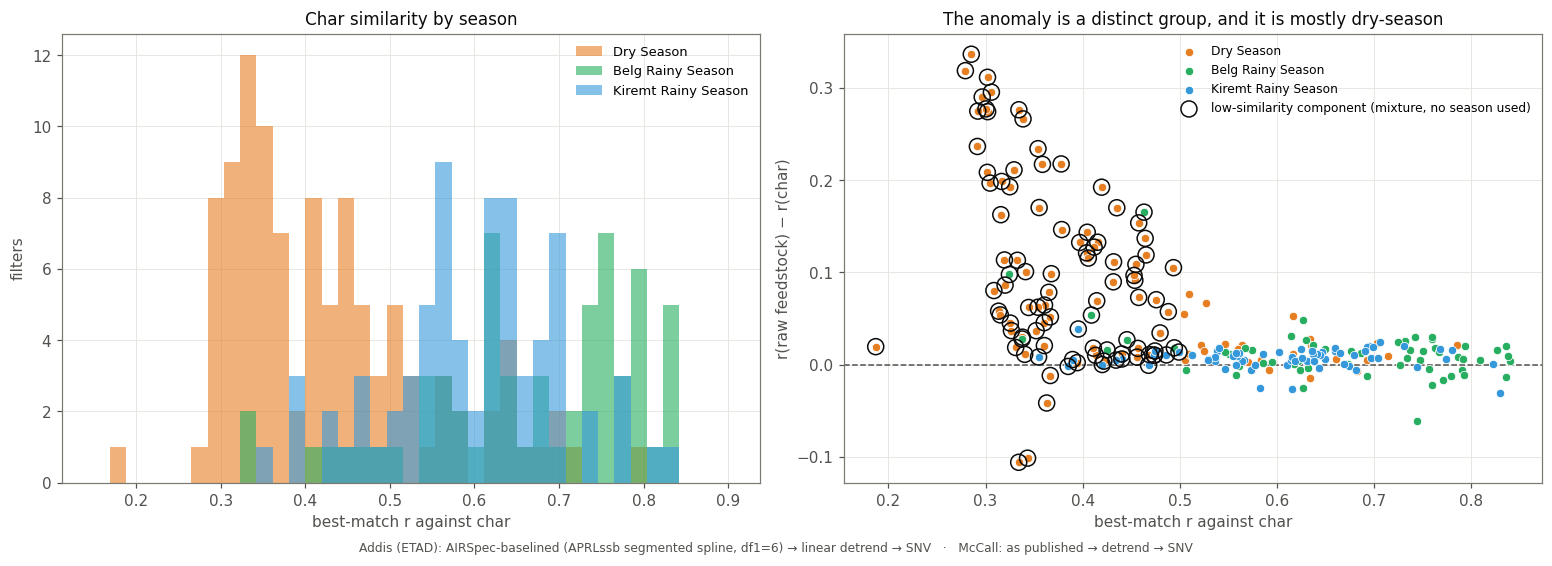

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

ax = axes[0]
bins = np.linspace(0.15, 0.9, 40)
for season, color in SEASON_COLORS.items():
    ax.hist(df.loc[df["season"] == season, "r_char"], bins=bins, color=color,
            alpha=0.6, label=season)
ax.set_xlabel("best-match r against char", color=INK2)
ax.set_ylabel("filters", color=INK2)
ax.set_title("Char similarity by season", color=INK)
ax.legend(fontsize=8.5)

ax = axes[1]
for season, color in SEASON_COLORS.items():
    m = (df["season"] == season).to_numpy()
    ax.scatter(df.loc[m, "r_char"], df.loc[m, "delta"], s=30, c=color,
               edgecolor="white", linewidth=0.5, label=season, zorder=3)
low = df["component"] == "low-similarity"
ax.scatter(df.loc[low, "r_char"], df.loc[low, "delta"], s=110, facecolor="none",
           edgecolor=INK, linewidth=1.0, zorder=4,
           label="low-similarity component (mixture, no season used)")
ax.axhline(0, color=INK2, lw=1, ls="--")
ax.set_xlabel("best-match r against char", color=INK2)
ax.set_ylabel("r(raw feedstock) − r(char)", color=INK2)
ax.set_title("The anomaly is a distinct group, and it is mostly dry-season", color=INK)
ax.legend(fontsize=8, loc="upper right")

stamp(fig)
fig.savefig(PLOT_DIR / "02_two_populations.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. What do the anomalous spectra look like?

Mean spectrum of the low-similarity group against everything else, and their difference.

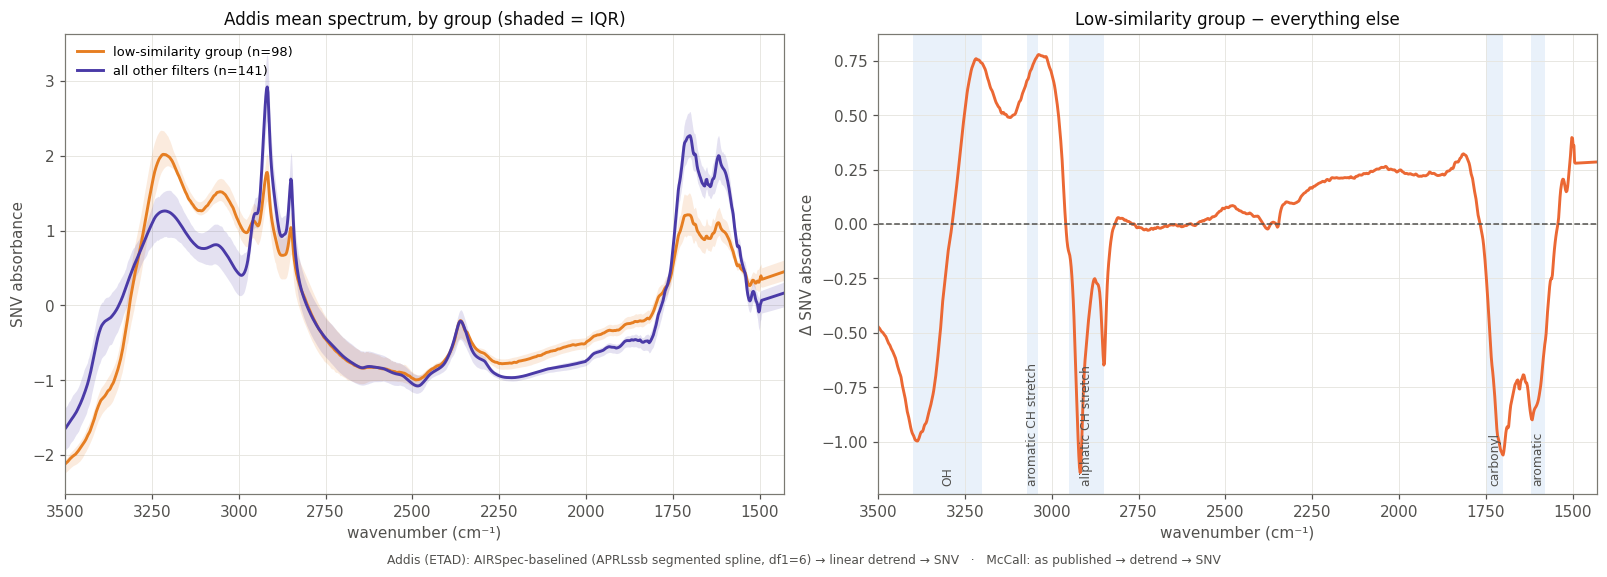

In [7]:
low_m = (df["component"] == "low-similarity").to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.9), constrained_layout=True)

ax = axes[0]
for m, color, label in [(low_m, SEASON_COLORS["Dry Season"],
                         f"low-similarity group (n={low_m.sum()})"),
                        (~low_m, ADDIS_COLOR, f"all other filters (n={(~low_m).sum()})")]:
    mu = X_addis[m].mean(0)
    q1, q3 = np.percentile(X_addis[m], [25, 75], axis=0)
    ax.plot(GRID, mu, color=color, lw=1.9, label=label)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.15, lw=0)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Addis mean spectrum, by group (shaded = IQR)", color=INK)
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1]
diff = X_addis[low_m].mean(0) - X_addis[~low_m].mean(0)
ax.plot(GRID, diff, color=SERIES[1], lw=1.9)
ax.axhline(0, color=INK2, lw=1, ls="--")
for name in ["OH / NH stretch", "aromatic CH stretch", "aliphatic CH stretch",
             "carbonyl C=O", "aromatic C=C"]:
    lo, hi = BANDS[name]
    if lo < GRID.min():
        continue
    ax.axvspan(lo, hi, color=SERIES[0], alpha=0.10, lw=0, zorder=0)
    ax.annotate(name.split(" /")[0].split(" C=")[0], xy=((lo + hi) / 2, ax.get_ylim()[0]),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2, rotation=90)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("Δ SNV absorbance", color=INK2)
ax.set_title("Low-similarity group − everything else", color=INK)

stamp(fig)
fig.savefig(PLOT_DIR / "03_anomalous_spectra.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view of the group means** — same split, unit-area scaling instead of SNV,
so the two groups read as band intensity. The Δ panel has no companion: subtraction
is defined on the common SNV footing.

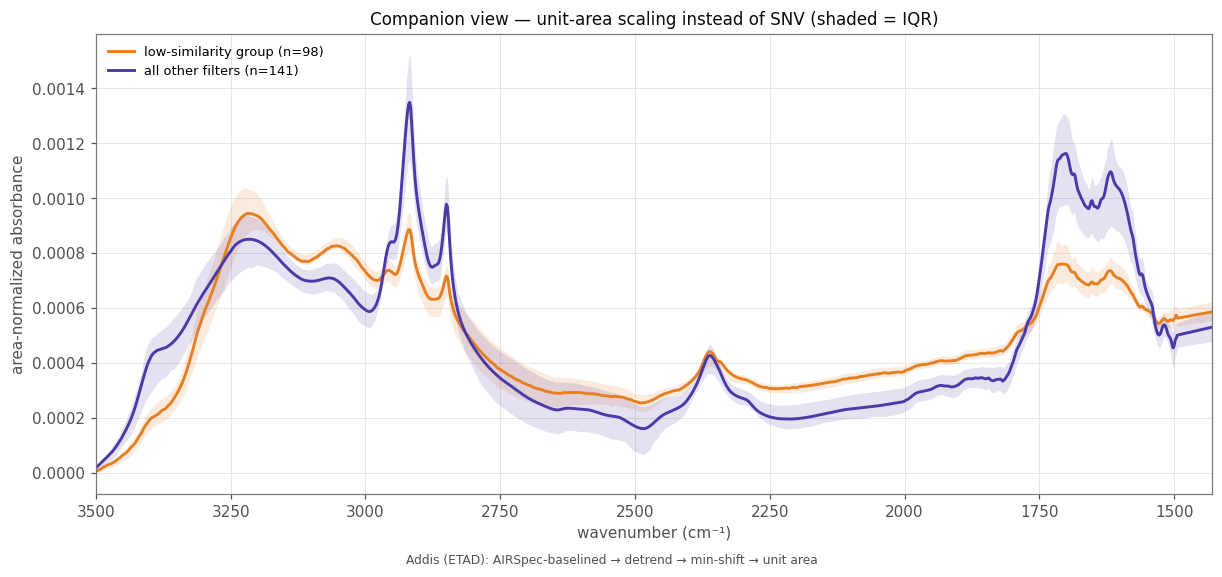

,low-similarity,other filters,difference
OH / NH stretch,0.37,0.53,-0.15
aromatic CH stretch,1.50,0.78,0.72
aliphatic CH stretch,1.06,1.58,-0.51
carbonyl C=O,0.99,1.73,-0.73
aromatic C=C,0.96,1.74,-0.78



per-filter classification written for all 239 filters


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.9), constrained_layout=True)
for m, color, label in [(low_m, SEASON_COLORS["Dry Season"],
                         f"low-similarity group (n={low_m.sum()})"),
                        (~low_m, ADDIS_COLOR, f"all other filters (n={(~low_m).sum()})")]:
    mu = X_addis_shape[m].mean(0)
    q1, q3 = np.percentile(X_addis_shape[m], [25, 75], axis=0)
    ax.plot(GRID, mu, color=color, lw=1.9, label=label)
    ax.fill_between(GRID, q1, q3, color=color, alpha=0.15, lw=0)
ax.set_xlim(GRID.max(), GRID.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV (shaded = IQR)",
             color=INK)
ax.legend(fontsize=8.5, loc="upper left")
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "03b_anomalous_spectra_shape.png", dpi=160, bbox_inches="tight")
plt.show()

band_tab = pd.DataFrame({
    "low-similarity": {n: band_area(X_addis[low_m], GRID, w).mean()
                       for n, w in BANDS.items() if w[0] >= GRID.min()},
    "other filters": {n: band_area(X_addis[~low_m], GRID, w).mean()
                      for n, w in BANDS.items() if w[0] >= GRID.min()},
})
band_tab["difference"] = band_tab["low-similarity"] - band_tab["other filters"]
display(band_tab.round(2))
band_tab.round(3).to_csv(TABLE_DIR / "band_difference.csv")

df[["FilterId", "date", "season", "LotId", "r_char", "r_raw", "delta", "component",
    "Fabs", "EC"]].sort_values("date").to_csv(
    TABLE_DIR / "per_filter_classification.csv", index=False)
print(f"\nper-filter classification written for all {len(df)} filters")

## 5. Is it really the season, or is it just low loading?

The anomalous filters carry less absorbing material. That raises a competing
explanation: thin deposits give noisier spectra, and noise lowers correlation with any
reference. If that were the whole story, season would drop out once loading is
controlled for. Logistic regression tests season and loading against each other.

In [9]:
model_df = df.dropna(subset=["Fabs", "EC"]).copy()
model_df["y"] = (model_df["component"] == "low-similarity").astype(int)
print("group medians:")
display(model_df.groupby("component")[["Fabs", "EC", "r_char"]].median().round(2))

import statsmodels.api as sm

results = {}
for name, cols in [("season only", ["is_dry"]),
                   ("loading only", ["Fabs", "EC"]),
                   ("season + loading", ["is_dry", "Fabs", "EC"])]:
    Xd = sm.add_constant(model_df[cols].astype(float))
    fit = sm.Logit(model_df["y"], Xd).fit(disp=0)
    results[name] = {"pseudo R²": fit.prsquared, "AIC": fit.aic,
                     **{f"p({c})": fit.pvalues.get(c, np.nan) for c in
                        ["is_dry", "Fabs", "EC"]}}
res = pd.DataFrame(results).T.round(4)
display(res)
res.to_csv(TABLE_DIR / "competing_explanations.csv")

print("\nAnd the reverse check — within the dry season alone, does loading separate the "
      "two groups?")
dsub = model_df[model_df["is_dry"]]
for col in ["Fabs", "EC"]:
    x = dsub.loc[dsub["y"] == 1, col]
    y = dsub.loc[dsub["y"] == 0, col]
    u = stats.mannwhitneyu(x, y)
    print(f"  {col:5s}: anomalous median {x.median():.2f} vs normal {y.median():.2f}, "
          f"p={u.pvalue:.3f}")

group medians:


,Fabs,EC,r_char
component,,,
low-similarity,43.31,3.45,0.39
normal,50.12,5.58,0.64


,pseudo R²,AIC,p(is_dry),p(Fabs),p(EC)
season only,0.2694,186.7123,0.0,NaN,NaN
loading only,0.1763,211.9874,NaN,0.9253,0.0013
season + loading,0.2931,184.7794,0.0,0.3080,0.6893



And the reverse check — within the dry season alone, does loading separate the two groups?
  Fabs : anomalous median 42.48 vs normal 44.63, p=0.516
  EC   : anomalous median 3.27 vs normal 3.13, p=0.724


### The other competing explanation: are these just bad spectra?

A thin or poor deposit gives a noisy spectrum, and noise lowers correlation with any
reference — which would produce exactly this pattern for entirely uninteresting reasons.
Two measurements settle it: **roughness** (the scatter of the second difference, a noise
proxy) and **within-group coherence** (how similar the group's members are to each
other). Noise raises the first and lowers the second.

In [10]:
roughness = np.std(np.diff(X_addis, n=2, axis=1), axis=1)
Z = zrows(X_addis)


def coherence(mask):
    S = (Z[mask] @ Z[mask].T) / GRID.size
    iu = np.triu_indices(int(mask.sum()), 1)
    return np.median(S[iu])


u_rough = stats.mannwhitneyu(roughness[low_m], roughness[~low_m])
dry_np = df["is_dry"].to_numpy()
u_rough_dry = stats.mannwhitneyu(roughness[dry_np & low_m], roughness[dry_np & ~low_m])
quality = pd.DataFrame({
    "roughness (noise proxy)": [np.median(roughness[low_m]), np.median(roughness[~low_m])],
    "within-group coherence (median pairwise r)": [coherence(low_m), coherence(~low_m)],
}, index=["low-similarity group", "other filters"]).round(4)
display(quality)
quality.to_csv(TABLE_DIR / "spectral_quality.csv")
print(f"roughness, low vs other: p={u_rough.pvalue:.1e}")
print(f"roughness within the dry season only: p={u_rough_dry.pvalue:.1e}")
print("\nThe anomalous spectra are *less* noisy and *more* internally coherent than the "
      "rest.\nThey are not degraded measurements — they are a tight, distinct spectral "
      "type.")

,roughness (noise proxy),within-group coherence (median pairwise r)
low-similarity group,0.0087,0.9539
other filters,0.0142,0.9312


roughness, low vs other: p=9.4e-23
roughness within the dry season only: p=1.4e-07

The anomalous spectra are *less* noisy and *more* internally coherent than the rest.
They are not degraded measurements — they are a tight, distinct spectral type.


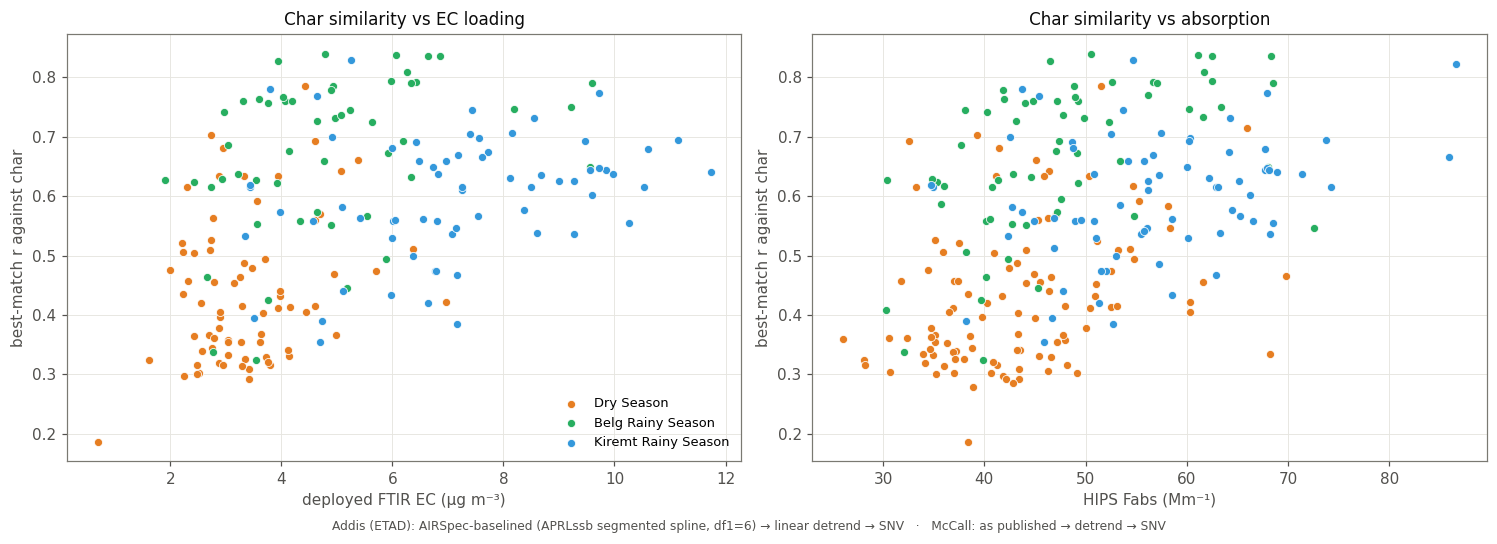

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), constrained_layout=True)
for ax, col, lab in [(axes[0], "EC", "deployed FTIR EC (µg m⁻³)"),
                     (axes[1], "Fabs", "HIPS Fabs (Mm⁻¹)")]:
    for season, color in SEASON_COLORS.items():
        m = (df["season"] == season).to_numpy() & df[col].notna().to_numpy()
        ax.scatter(df.loc[m, col], df.loc[m, "r_char"], s=28, c=color,
                   edgecolor="white", linewidth=0.5, label=season, zorder=3)
    ax.set_xlabel(lab, color=INK2)
    ax.set_ylabel("best-match r against char", color=INK2)
axes[0].set_title("Char similarity vs EC loading", color=INK)
axes[1].set_title("Char similarity vs absorption", color=INK)
axes[0].legend(fontsize=8.5, loc="lower right")
stamp(fig)
fig.savefig(PLOT_DIR / "04_loading_check.png", dpi=160, bbox_inches="tight")
plt.show()

## Takeaways

- **The dry-season anomaly is real, and it is not the filter lot.** Within lot 251
  alone — which spans all three seasons — dry-season filters separate at
  **p ≈ 9×10⁻¹²** (median char-similarity 0.400 vs 0.731 Belg, 0.616 Kiremt). Within the
  dry season alone, the two lots are indistinguishable (**p = 0.89**). The effect follows
  the calendar, not the filter stock.
- **It recurs every year, which no instrument artifact does.** The anomaly rate is
  82 % in November, 61 % in December, ~48 % in January–February, 50 % in October — and
  **exactly zero in May through September**, repeating across four sampling years. An
  instrument or handling problem does not switch off every March and back on every
  October.
- **The dry season is two populations, not one shifted population.** A two-component
  Gaussian mixture fitted to char-similarity with **no season information** is preferred
  over one component (BIC −214.9 vs −202.3) and splits at means 0.393 / 0.649. **75 % of
  dry-season filters (79 of 105)** fall in the low-similarity component; the other 26 are
  indistinguishable from wet-season filters. So roughly a quarter of dry-season days look
  entirely ordinary — this is an episodic phenomenon, not a seasonal baseline shift.
- **It is not a loading artifact.** Anomalous filters do carry less EC overall, but that
  is a between-season difference: within the dry season, loading does **not** separate the
  two groups (Fabs p = 0.52, EC p = 0.72). In a logistic model with both predictors,
  season stays at p ≈ 0 while Fabs (0.31) and EC (0.69) both go non-significant — season
  absorbs loading's apparent effect entirely.
- **It is not poor spectral quality either — the opposite.** The anomalous spectra are
  **less** noisy (roughness 0.0087 vs 0.0142, p < 0.001, and the same within the dry
  season) and **more** internally coherent (median pairwise r 0.954 vs 0.931). They are a
  tight, well-measured, mutually consistent spectral type that simply does not match the
  charcoal references.
- **What distinguishes them spectrally**: relative to all other filters they run lower in
  aromatic C=C (−0.78 SNV), carbonyl (−0.74) and aliphatic C–H (−0.51), and markedly
  higher in the narrow 3040–3070 cm⁻¹ aromatic C–H window (+0.72). Fewer of the bands
  that charcoal is matched on, which is mechanically why the correlation falls.

**What this does not establish.** The direction of the band shifts is descriptive, not
diagnostic: three of the five bands falling together in SNV-normalized data is also what
a flatter, less-featured spectrum looks like, and the 3040–3070 window is narrow and sits
on the shoulder of the main C–H envelope. Naming the responsible aerosol component would
need the C–O fingerprint region this comparison cannot see, and ideally collocated
composition data. The defensible claim is the control-tested one: **a distinct, coherent,
episodic spectral type appears at Addis in October–February, on roughly three-quarters of
dry-season filters, and it is not explained by filter lot, deposit loading, or spectral
noise.**

That makes it a lead worth following with the dry-season quartz TOR campaign already
proposed in phase 3 — the anomalous days are a concrete, pre-specified target list, and
`output/tables/char06/` carries the per-filter classification.